# Data Science with Python Internship – Task 4
## Mini Visualization Dashboard (Matplotlib + Seaborn) — Titanic Dataset

**Maincrafts Technology**

## Overview

This notebook builds a mini data-visualization dashboard on the Titanic
dataset. It covers data cleaning, two engineered features (`AgeGroup`,
`FamilySize`), five distinct chart types, and a short written interpretation
under each figure.


## Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()
%matplotlib inline


## Load the Dataset

Column names are standardized to the common Kaggle Titanic convention.


In [2]:
df = pd.read_csv("titanic.csv")

df = df.rename(columns={
    "survived": "Survived",
    "pclass": "Pclass",
    "sex": "Sex",
    "age": "Age",
    "sibsp": "SibSp",
    "parch": "Parch",
    "fare": "Fare",
    "embarked": "Embarked",
    "class": "Class",
    "who": "Who",
    "adult_male": "Adult_Male",
    "deck": "Deck",
    "embark_town": "Embark_Town",
    "alive": "Alive",
    "alone": "Alone",
})

print(df.head())
print(df.info())


   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked  Class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     Who  Adult_Male Deck  Embark_Town Alive  Alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  

## Cleaning

- Fill missing `Age` with the median.
- Fill missing `Embarked` with the mode.
- Drop `Deck`/`Cabin` — too sparse to be useful.


In [3]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns=["Deck"], errors="ignore")

df.isnull().sum().sort_values(ascending=False)


Embark_Town    2
Survived       0
Sex            0
Age            0
SibSp          0
Pclass         0
Parch          0
Fare           0
Class          0
Embarked       0
Who            0
Adult_Male     0
Alive          0
Alone          0
dtype: int64

## Features

- `FamilySize` = `SibSp` + `Parch` (+ self, per Task 4's starter code this is
  just `SibSp + Parch`, i.e. family members excluding the passenger).
- `AgeGroup` — Child / Teen / YoungAdult / Adult / Senior buckets.


In [4]:
df["FamilySize"] = df["SibSp"] + df["Parch"]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
)

df[["Age", "AgeGroup", "SibSp", "Parch", "FamilySize"]].head()


,Age,AgeGroup,SibSp,Parch,FamilySize
0,22.0,YoungAdult,1,0,1
1,38.0,Adult,1,0,1
2,26.0,YoungAdult,0,0,0
3,35.0,Adult,1,0,1
4,35.0,Adult,0,0,0


## Visualizations

### 1. Histogram — Age Distribution

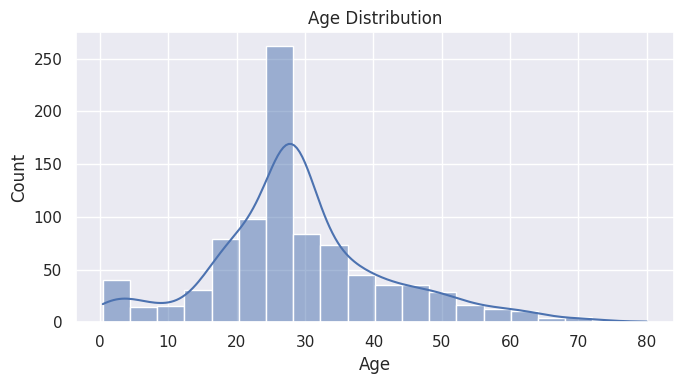

In [5]:
plt.figure(figsize=(7, 4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("images/01_age_histogram.png", dpi=150)
plt.show()


**Insight:** Most passengers were young adults in their 20s-30s, with a
smaller secondary bump of young children — the median-age fill slightly
sharpens the peak around the overall median.


### 2. Bar Chart — Survival Rate by Gender

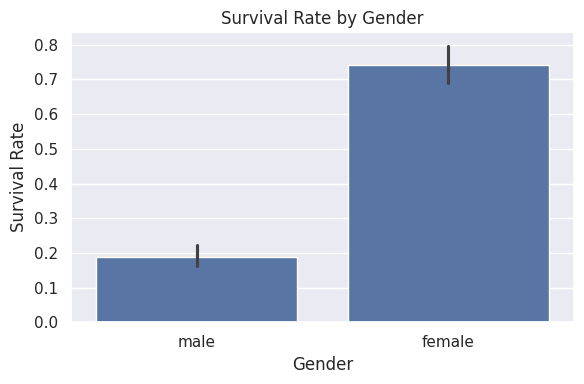

In [6]:
plt.figure(figsize=(6, 4))
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.savefig("images/02_survival_by_gender.png", dpi=150)
plt.show()


**Insight:** Women survived at a far higher rate than men, consistent with
the evacuation's "women and children first" priority.


### 3. Boxplot — Fare Distribution by Passenger Class

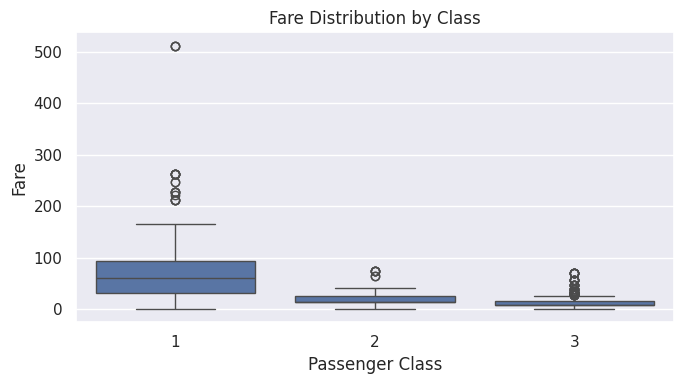

In [7]:
plt.figure(figsize=(7, 4))
sns.boxplot(x="Pclass", y="Fare", data=df)
plt.title("Fare Distribution by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.tight_layout()
plt.savefig("images/03_fare_by_class_boxplot.png", dpi=150)
plt.show()


**Insight:** 1st class fares are much higher and far more spread out, with
several high-fare outliers, while 2nd and 3rd class fares are low and tightly
clustered.


### 4. Scatterplot — Age vs. Fare, Colored by Survival

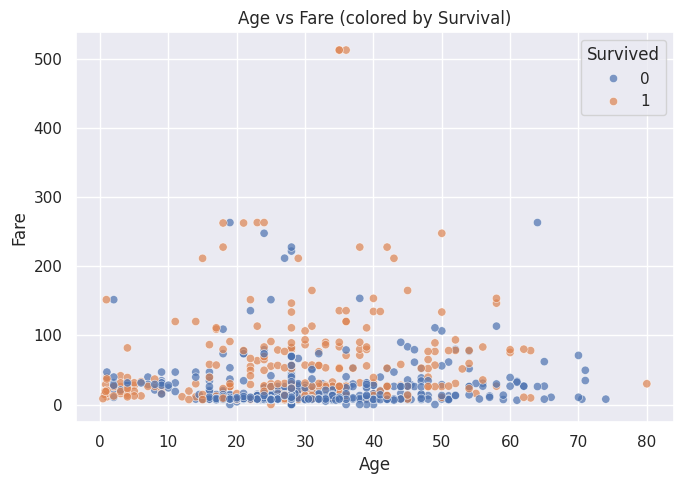

In [8]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=df, alpha=0.7)
plt.title("Age vs Fare (colored by Survival)")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.tight_layout()
plt.savefig("images/04_age_vs_fare_scatter.png", dpi=150)
plt.show()


**Insight:** Survivors (orange) skew toward higher fares across most ages,
reinforcing that passengers who paid more (and were likely in higher classes)
had better survival odds regardless of age.


### 5. Heatmap — Correlation of Numeric Columns

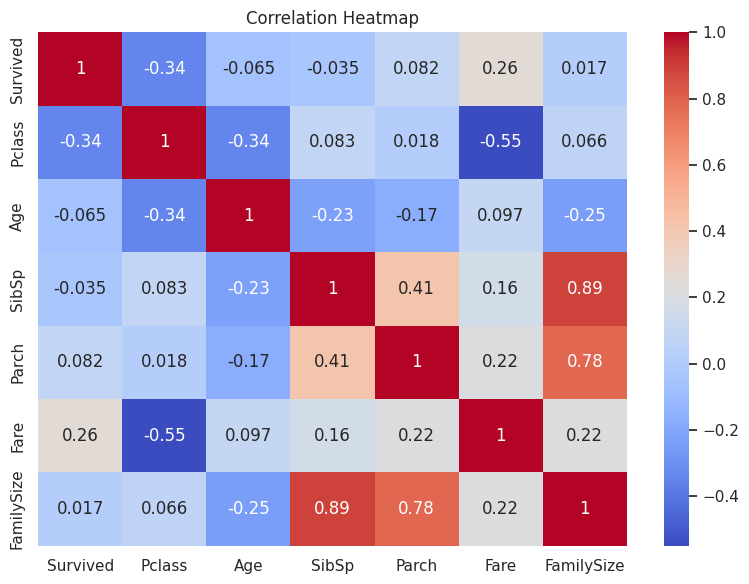

In [9]:
plt.figure(figsize=(8, 6))
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("images/05_correlation_heatmap.png", dpi=150)
plt.show()


**Insight:** `Fare` has the strongest positive correlation with `Survived`,
while `Pclass` has the strongest negative correlation — both point to
socioeconomic status being the biggest driver of survival among numeric
features.


### Bonus: Facet Grid — Survival by Class, Split by Gender

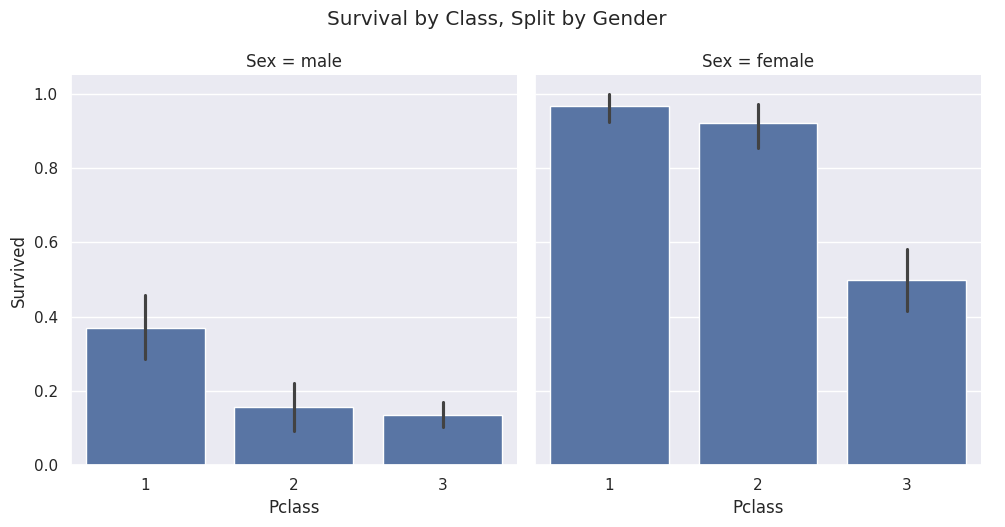

In [10]:
g = sns.catplot(col="Sex", x="Pclass", y="Survived", kind="bar", data=df)
g.fig.suptitle("Survival by Class, Split by Gender", y=1.05)
g.savefig("images/06_survival_facet_by_sex.png", dpi=150)
plt.show()


**Insight:** The class effect on survival holds for both genders, but it is
much steeper for men — male survival collapses in 3rd class, while female
survival stays comparatively high across all three classes.


## Insights

- **Gender** was the single biggest survival factor — women survived far more
  often than men at every class level.
- **Class and Fare** are closely tied to survival — wealthier, higher-class
  passengers had a clear advantage.
- **Age** shows a mild effect (children fared slightly better) but is far
  weaker than gender or class.
- **Family Size** and `SibSp`/`Parch` show only weak direct correlation with
  survival on their own.


## Conclusion

The Titanic dashboard shows survival was driven primarily by **gender** and
**socioeconomic status** (class/fare), with age playing a smaller role. These
patterns match the historical account of the evacuation and demonstrate how a
handful of well-chosen charts — histogram, bar chart, boxplot, scatterplot,
and heatmap — can tell a complete data story.
